### Khai báo Thư viện, Cấu hình và Hàm dùng chung

In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import warnings
import gc
import time

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})

# Kiểm tra thiết bị (Sẽ dùng cuda:0 cho RTX 4060)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Đang sử dụng thiết bị: {device}")

# Định nghĩa map nhãn toàn cục
label_map = {'entailment': 0, 'neutral': 1, 'contradiction': 2}
reverse_label_map = {0: 'entailment', 1: 'neutral', 2: 'contradiction'}
loss_fn = nn.CrossEntropyLoss()

# Hàm Đánh Giá dùng chung cho tất cả các model
def evaluate_model(eval_model, dataloader, eval_device):
    eval_model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(eval_device)
            attention_mask = batch['attention_mask'].to(eval_device)
            labels = batch['labels'].to(eval_device)
            
            with autocast():
                logits, _ = eval_model(input_ids, attention_mask)
                loss = loss_fn(logits, labels)
                
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            
    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, macro_f1

print("✅ Đã tải xong thư viện và hàm dùng chung!")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Đang sử dụng thiết bị: cuda
✅ Đã tải xong thư viện và hàm dùng chung!


### Chuẩn bị Dữ liệu cho PhoBERT

In [2]:
print("="*50)
print("📦 BƯỚC 1: CHUẨN BỊ DỮ LIỆU CHO PHOBERT")
print("="*50)

phobert_name = "vinai/phobert-base"
phobert_tokenizer = AutoTokenizer.from_pretrained(phobert_name)

class ViNLIDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=256):
        self.data = pd.read_csv(csv_file).dropna().reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        premise = str(self.data.loc[idx, 'premise'])
        hypothesis = str(self.data.loc[idx, 'hypothesis'])
        label_str = str(self.data.loc[idx, 'label']).strip().lower()
        
        encoding = self.tokenizer(
            premise, hypothesis,
            add_special_tokens=True, max_length=self.max_length,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label_map[label_str], dtype=torch.long)
        }

# Batch_size 16 cho V1, Batch_size 8 cho V2
train_dataset_pb = ViNLIDataset('train.csv', phobert_tokenizer)
val_dataset_pb = ViNLIDataset('validation.csv', phobert_tokenizer)
test_dataset_pb = ViNLIDataset('test.csv', phobert_tokenizer)

print(f"✅ Hoàn tất tải Data PhoBERT! Số mẫu Train: {len(train_dataset_pb)}")

📦 BƯỚC 1: CHUẨN BỊ DỮ LIỆU CHO PHOBERT
✅ Hoàn tất tải Data PhoBERT! Số mẫu Train: 8012


### EXPERIMENT 1 - PhoBERT MoE V1 (Khởi tạo & Train)

In [3]:
print("\n" + "="*50)
print("🔬 EXPERIMENT 1: PhoBERT-base + MoE V1 (Soft-Routing, Đóng băng 8 layer)")
print("="*50)

# Dọn VRAM trước khi chạy
gc.collect()
torch.cuda.empty_cache()

class ReasoningAwareMoE_V1(nn.Module):
    def __init__(self, model_name="vinai/phobert-base", num_labels=3, num_experts=4):
        super().__init__()
        self.num_experts = num_experts
        self.phobert = AutoModel.from_pretrained(model_name)
        hidden_size = self.phobert.config.hidden_size
        
        for name, param in self.phobert.named_parameters():
            if 'encoder.layer' in name and int(name.split('.')[2]) < 8:
                param.requires_grad = False
                    
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_size, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, hidden_size)) for _ in range(num_experts)
        ])
        self.router = nn.Sequential(nn.Linear(hidden_size, 128), nn.Tanh(), nn.Linear(128, num_experts))
        self.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(hidden_size, num_labels))

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        cls_state = outputs.last_hidden_state[:, 0, :] 
        routing_weights = torch.softmax(self.router(cls_state), dim=-1)
        
        final_feature = torch.zeros_like(cls_state)
        for i, expert in enumerate(self.experts):
            final_feature += expert(cls_state) * routing_weights[:, i].unsqueeze(1)
            
        return self.classifier(final_feature), routing_weights

# --- KHỞI TẠO ---
model_v1 = ReasoningAwareMoE_V1().to(device)
train_loader_v1 = DataLoader(train_dataset_pb, batch_size=16, shuffle=True)
val_loader_v1 = DataLoader(val_dataset_pb, batch_size=16)
test_loader_v1 = DataLoader(test_dataset_pb, batch_size=16)

EPOCHS_V1 = 3
optimizer_v1 = AdamW(model_v1.parameters(), lr=2e-5, weight_decay=0.01)
total_steps_v1 = len(train_loader_v1) * EPOCHS_V1
scheduler_v1 = get_linear_schedule_with_warmup(optimizer_v1, num_warmup_steps=int(0.1 * total_steps_v1), num_training_steps=total_steps_v1)
scaler_v1 = GradScaler()

# --- TRAINING LOOP ---
for epoch in range(EPOCHS_V1):
    start_time = time.time()
    model_v1.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader_v1, desc=f"V1 Epoch {epoch+1}/{EPOCHS_V1}", leave=False)
    
    for batch in progress_bar:
        optimizer_v1.zero_grad()
        with autocast():
            logits, routing_weights = model_v1(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            loss = loss_fn(logits, batch['labels'].to(device))
            expert_usage = routing_weights.mean(dim=0)
            cv_loss = (expert_usage.var() / (expert_usage.mean()**2 + 1e-10))
            total_loss = loss + 0.1 * cv_loss
            
        scaler_v1.scale(total_loss).backward()
        scaler_v1.unscale_(optimizer_v1)
        torch.nn.utils.clip_grad_norm_(model_v1.parameters(), max_norm=1.0)
        scaler_v1.step(optimizer_v1)
        scaler_v1.update()
        scheduler_v1.step()
        
        total_train_loss += total_loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader_v1)
    val_loss, val_acc, val_f1 = evaluate_model(model_v1, val_loader_v1, device)
    print(f"✅ V1 Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {time.time() - start_time:.1f}s")


🔬 EXPERIMENT 1: PhoBERT-base + MoE V1 (Soft-Routing, Đóng băng 8 layer)


✅ V1 Epoch 1 | Train Loss: 1.0841 | Val Loss: 1.0703 | Val Acc: 0.4220 | Time: 86.3s


✅ V1 Epoch 2 | Train Loss: 1.0146 | Val Loss: 1.0578 | Val Acc: 0.4480 | Time: 84.6s


✅ V1 Epoch 3 | Train Loss: 0.9552 | Val Loss: 1.0715 | Val Acc: 0.4450 | Time: 84.8s


### EXPERIMENT 1 - Đánh giá & Vẽ Biểu Đồ


📊 ĐÁNH GIÁ EXPERIMENT 1 TRÊN TEST SET (ViANLI)


Testing V1: 100%|██████████| 63/63 [00:03<00:00, 19.97it/s]


🎯 V1 TEST ACCURACY: 0.4150
🎯 V1 TEST MACRO-F1: 0.4146


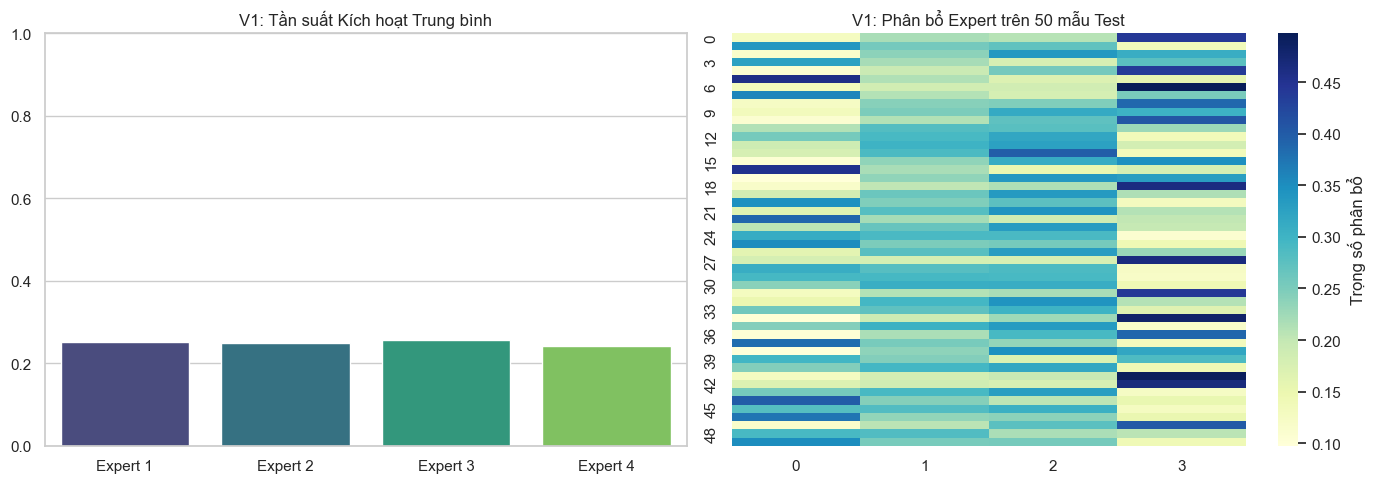

In [4]:
print("\n" + "="*50)
print("📊 ĐÁNH GIÁ EXPERIMENT 1 TRÊN TEST SET (ViANLI)")
print("="*50)

model_v1.eval()
test_preds, test_labels, all_routing_weights = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader_v1, desc="Testing V1"):
        with autocast():
            logits, routing_weights = model_v1(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        test_labels.extend(batch['labels'].to(device).cpu().numpy())
        all_routing_weights.append(routing_weights.cpu().numpy())

print(f"🎯 V1 TEST ACCURACY: {accuracy_score(test_labels, test_preds):.4f}")
print(f"🎯 V1 TEST MACRO-F1: {f1_score(test_labels, test_preds, average='macro'):.4f}")

# VẼ BIỂU ĐỒ
routing_matrix = np.concatenate(all_routing_weights, axis=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=[f"Expert {i+1}" for i in range(4)], y=routing_matrix.mean(axis=0), palette="viridis", ax=axes[0])
axes[0].set_title("V1: Tần suất Kích hoạt Trung bình")
axes[0].set_ylim(0, 1.0)

sns.heatmap(routing_matrix[:50], cmap="YlGnBu", cbar_kws={'label': 'Trọng số phân bổ'}, ax=axes[1])
axes[1].set_title("V1: Phân bổ Expert trên 50 mẫu Test")
plt.show()

### EXPERIMENT 2 - PhoBERT MoE V2 (Khởi tạo & Train)

In [5]:
print("\n" + "="*50)
print("🔬 EXPERIMENT 2: PhoBERT-base + MoE V2 (Top-2 Routing, Đóng băng 4 layer, Grad Accumulation)")
print("="*50)

# XÓA MODEL V1 ĐỂ TRÁNH TRÀN VRAM
try:
    del model_v1, optimizer_v1, scaler_v1
    gc.collect()
    torch.cuda.empty_cache()
    print("🧹 Đã dọn dẹp VRAM từ Experiment 1!")
except: pass

class ReasoningAwareMoE_V2(nn.Module):
    def __init__(self, model_name="vinai/phobert-base", num_labels=3, num_experts=4, top_k=2):
        super().__init__()
        self.num_experts, self.top_k = num_experts, top_k
        self.phobert = AutoModel.from_pretrained(model_name)
        hidden_size = self.phobert.config.hidden_size
        
        for name, param in self.phobert.named_parameters():
            if 'encoder.layer' in name and int(name.split('.')[2]) < 4: 
                param.requires_grad = False
                    
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_size, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, hidden_size)) for _ in range(num_experts)
        ])
        self.router = nn.Sequential(nn.Linear(hidden_size, 128), nn.Tanh(), nn.Linear(128, num_experts))
        self.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(hidden_size, num_labels))

    def forward(self, input_ids, attention_mask):
        cls_state = self.phobert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :] 
        routing_weights_full = torch.softmax(self.router(cls_state), dim=-1)
        
        topk_weights, topk_indices = torch.topk(routing_weights_full, k=self.top_k, dim=-1)
        mask = torch.zeros_like(routing_weights_full).scatter_(-1, topk_indices, topk_weights)
        mask = mask / (mask.sum(dim=-1, keepdim=True) + 1e-9)
        
        final_feature = torch.zeros_like(cls_state)
        for i, expert in enumerate(self.experts):
            final_feature += expert(cls_state) * mask[:, i].unsqueeze(1)
            
        return self.classifier(final_feature), routing_weights_full

# --- KHỞI TẠO ---
model_v2 = ReasoningAwareMoE_V2().to(device)
BATCH_SIZE_V2 = 8
ACCUMULATION_STEPS = 2
train_loader_v2 = DataLoader(train_dataset_pb, batch_size=BATCH_SIZE_V2, shuffle=True)
val_loader_v2 = DataLoader(val_dataset_pb, batch_size=BATCH_SIZE_V2)
test_loader_v2 = DataLoader(test_dataset_pb, batch_size=BATCH_SIZE_V2)

EPOCHS_V2 = 3 
optimizer_v2 = AdamW(model_v2.parameters(), lr=2e-5, weight_decay=0.01)
total_steps_v2 = (len(train_loader_v2) // ACCUMULATION_STEPS) * EPOCHS_V2
scheduler_v2 = get_linear_schedule_with_warmup(optimizer_v2, num_warmup_steps=int(0.1 * total_steps_v2), num_training_steps=total_steps_v2)
scaler_v2 = GradScaler() 

# --- TRAINING LOOP ---
for epoch in range(EPOCHS_V2):
    start_time = time.time()
    model_v2.train()
    total_train_loss = 0
    optimizer_v2.zero_grad()
    progress_bar = tqdm(train_loader_v2, desc=f"V2 Epoch {epoch+1}/{EPOCHS_V2}", leave=False)
    
    for step, batch in enumerate(progress_bar):
        with autocast():
            logits, routing_weights_full = model_v2(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            loss = loss_fn(logits, batch['labels'].to(device))
            expert_usage = routing_weights_full.mean(dim=0) 
            cv_loss = (expert_usage.var() / (expert_usage.mean()**2 + 1e-10))
            total_loss = (loss + 0.1 * cv_loss) / ACCUMULATION_STEPS
            
        scaler_v2.scale(total_loss).backward()
        
        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader_v2):
            scaler_v2.unscale_(optimizer_v2)
            torch.nn.utils.clip_grad_norm_(model_v2.parameters(), max_norm=1.0)
            scaler_v2.step(optimizer_v2)
            scaler_v2.update()
            scheduler_v2.step()
            optimizer_v2.zero_grad()
            
        total_train_loss += (total_loss.item() * ACCUMULATION_STEPS)
        
    avg_train_loss = total_train_loss / len(train_loader_v2)
    val_loss, val_acc, val_f1 = evaluate_model(model_v2, val_loader_v2, device)
    print(f"✅ V2 Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {time.time() - start_time:.1f}s")


🔬 EXPERIMENT 2: PhoBERT-base + MoE V2 (Top-2 Routing, Đóng băng 4 layer, Grad Accumulation)
🧹 Đã dọn dẹp VRAM từ Experiment 1!


✅ V2 Epoch 1 | Train Loss: 1.0800 | Val Loss: 1.0991 | Val Acc: 0.3800 | Time: 106.4s


✅ V2 Epoch 2 | Train Loss: 1.0310 | Val Loss: 1.0548 | Val Acc: 0.4290 | Time: 111.5s


✅ V2 Epoch 3 | Train Loss: 0.9758 | Val Loss: 1.0667 | Val Acc: 0.4340 | Time: 108.1s


### EXPERIMENT 2 - Đánh giá, Vẽ Biểu Đồ & Trích xuất lỗi


📊 ĐÁNH GIÁ EXPERIMENT 2 TRÊN TEST SET (ViANLI)
🎯 V2 TEST ACCURACY: 0.4280
🎯 V2 TEST MACRO-F1: 0.3439
🚨 Đã xuất 572 câu sai ra file 'error_analysis_vianli.csv'


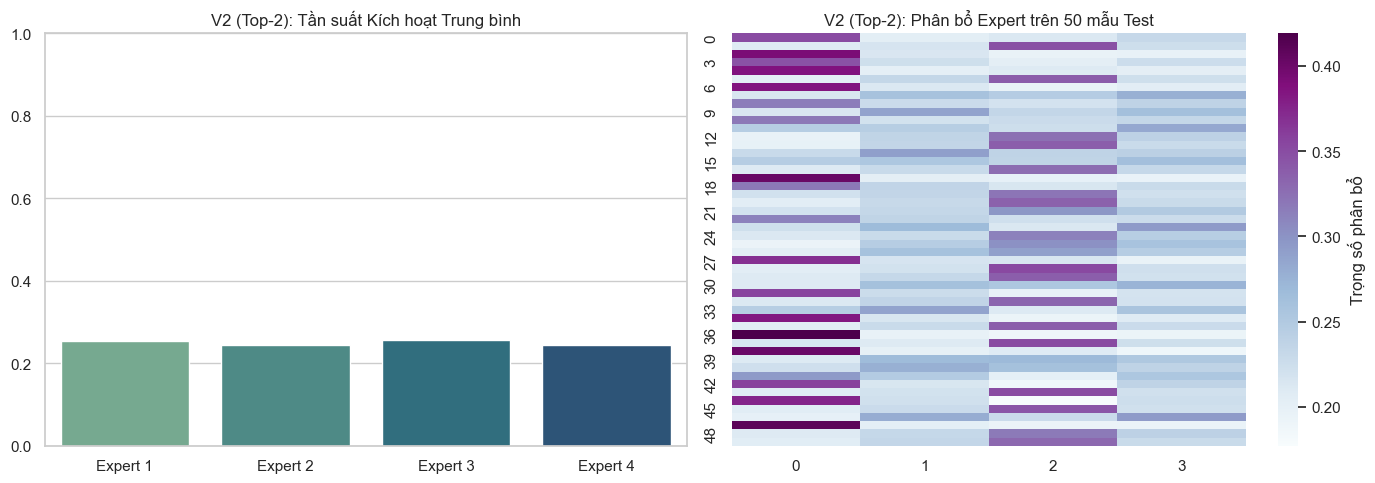

In [6]:
print("\n" + "="*50)
print("📊 ĐÁNH GIÁ EXPERIMENT 2 TRÊN TEST SET (ViANLI)")
print("="*50)

model_v2.eval()
test_preds_v2, test_labels_v2, all_routing_weights_v2 = [], [], []
error_df = []

with torch.no_grad():
    for batch_idx, (batch, original_idx) in enumerate(zip(test_loader_v2, range(0, len(test_dataset_pb), BATCH_SIZE_V2))):
        with autocast():
            logits, routing_weights = model_v2(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        
        preds = torch.argmax(logits, dim=1)
        labels = batch['labels'].to(device)
        
        test_preds_v2.extend(preds.cpu().numpy())
        test_labels_v2.extend(labels.cpu().numpy())
        all_routing_weights_v2.append(routing_weights.cpu().numpy())
        
        # ERROR ANALYSIS
        wrong_mask = (preds != labels)
        if wrong_mask.any():
            wrong_indices = torch.where(wrong_mask)[0]
            for idx in wrong_indices:
                real_idx = original_idx + idx.item()
                if real_idx < len(test_dataset_pb):
                    row = test_dataset_pb.data.iloc[real_idx]
                    error_df.append({
                        'premise': row['premise'], 'hypothesis': row['hypothesis'],
                        'true_label': reverse_label_map[labels[idx].item()],
                        'pred_label': reverse_label_map[preds[idx].item()]
                    })

print(f"🎯 V2 TEST ACCURACY: {accuracy_score(test_labels_v2, test_preds_v2):.4f}")
print(f"🎯 V2 TEST MACRO-F1: {f1_score(test_labels_v2, test_preds_v2, average='macro'):.4f}")

# XUẤT ERROR CSV
pd.DataFrame(error_df).to_csv("error_analysis_vianli.csv", index=False, encoding='utf-8-sig')
print(f"🚨 Đã xuất {len(error_df)} câu sai ra file 'error_analysis_vianli.csv'")

# VẼ BIỂU ĐỒ
routing_matrix_v2 = np.concatenate(all_routing_weights_v2, axis=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=[f"Expert {i+1}" for i in range(4)], y=routing_matrix_v2.mean(axis=0), palette="crest", ax=axes[0])
axes[0].set_title("V2 (Top-2): Tần suất Kích hoạt Trung bình")
axes[0].set_ylim(0, 1.0)

sns.heatmap(routing_matrix_v2[:50], cmap="BuPu", cbar_kws={'label': 'Trọng số phân bổ'}, ax=axes[1])
axes[1].set_title("V2 (Top-2): Phân bổ Expert trên 50 mẫu Test")
plt.show()

### Chuẩn bị Dữ liệu cho XLM-RoBERTa

In [7]:
print("="*50)
print("📦 BƯỚC 2: CHUẨN BỊ DỮ LIỆU CHO XLM-RoBERTa")
print("="*50)

# Import lại Tokenizer để đảm bảo không bị NameError
from transformers import AutoTokenizer

xlmr_name = "xlm-roberta-base"
xlmr_tokenizer = AutoTokenizer.from_pretrained(xlmr_name)

class ViNLIDataset_XLMR(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=256):
        self.data = pd.read_csv(csv_file).dropna().reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # XML-R Tokenizer tự xử lý cấu trúc đa ngôn ngữ
        encoding = self.tokenizer(
            str(self.data.loc[idx, 'premise']), str(self.data.loc[idx, 'hypothesis']),
            add_special_tokens=True, max_length=self.max_length,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label_map[str(self.data.loc[idx, 'label']).strip().lower()], dtype=torch.long)
        }

XLMR_BATCH_SIZE = 8
train_dataset_xlmr = ViNLIDataset_XLMR('train.csv', xlmr_tokenizer)
val_dataset_xlmr = ViNLIDataset_XLMR('validation.csv', xlmr_tokenizer)
test_dataset_xlmr = ViNLIDataset_XLMR('test.csv', xlmr_tokenizer)

train_loader_xlmr = DataLoader(train_dataset_xlmr, batch_size=XLMR_BATCH_SIZE, shuffle=True)
val_loader_xlmr = DataLoader(val_dataset_xlmr, batch_size=XLMR_BATCH_SIZE)
test_loader_xlmr = DataLoader(test_dataset_xlmr, batch_size=XLMR_BATCH_SIZE)

print("✅ Hoàn tất tải Data XLM-R!")

📦 BƯỚC 2: CHUẨN BỊ DỮ LIỆU CHO XLM-RoBERTa
✅ Hoàn tất tải Data XLM-R!


### EXPERIMENT 3 - XLM-R MoE V2 (Khởi tạo & Train)

In [8]:
print("\n" + "="*50)
print("🔬 EXPERIMENT 3: XLM-R-base + MoE V2 (Heavy Experts, Top-2 Routing)")
print("="*50)

# XÓA MODEL V2 ĐỂ TRÁNH TRÀN VRAM
try:
    del model_v2, optimizer_v2, scaler_v2
    gc.collect()
    torch.cuda.empty_cache()
    print("🧹 Đã dọn dẹp VRAM từ Experiment 2!")
except: pass

class ReasoningAwareMoE_XLMR(nn.Module):
    def __init__(self, model_name="xlm-roberta-base", num_labels=3, num_experts=4, top_k=2):
        super().__init__()
        self.num_experts, self.top_k = num_experts, top_k
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size 
        
        # Đóng băng 6 layer đầu (XLM-R base có 12 layer)
        for name, param in self.backbone.named_parameters():
            if 'encoder.layer' in name and int(name.split('.')[2]) < 6: 
                param.requires_grad = False
                    
        # NÂNG CẤP SỨC MẠNH EXPERT (Dymension 512)
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_size, 512), nn.GELU(), nn.Dropout(0.1), nn.Linear(512, hidden_size)) for _ in range(num_experts)
        ])
        self.router = nn.Sequential(nn.Linear(hidden_size, 256), nn.Tanh(), nn.Linear(256, num_experts))
        self.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(hidden_size, num_labels))

    def forward(self, input_ids, attention_mask):
        cls_state = self.backbone(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :] 
        routing_weights_full = torch.softmax(self.router(cls_state), dim=-1)
        
        topk_weights, topk_indices = torch.topk(routing_weights_full, k=self.top_k, dim=-1)
        mask = torch.zeros_like(routing_weights_full).scatter_(-1, topk_indices, topk_weights)
        mask = mask / (mask.sum(dim=-1, keepdim=True) + 1e-9)
        
        final_feature = torch.zeros_like(cls_state)
        for i, expert in enumerate(self.experts):
            final_feature += expert(cls_state) * mask[:, i].unsqueeze(1)
            
        return self.classifier(final_feature), routing_weights_full

# --- KHỞI TẠO ---
print("⏳ Đang nạp XLM-R lên GPU...")
xlmr_model = ReasoningAwareMoE_XLMR().to(device)

EPOCHS_XLMR = 3 
LEARNING_RATE_XLMR = 1.5e-5 # XLM-R cần LR nhỏ hơn
ACCUMULATION_STEPS = 2

optimizer_xlmr = AdamW(xlmr_model.parameters(), lr=LEARNING_RATE_XLMR, weight_decay=0.01)
total_steps_xlmr = (len(train_loader_xlmr) // ACCUMULATION_STEPS) * EPOCHS_XLMR
scheduler_xlmr = get_linear_schedule_with_warmup(optimizer_xlmr, num_warmup_steps=int(0.1 * total_steps_xlmr), num_training_steps=total_steps_xlmr)
scaler_xlmr = GradScaler()
optimizer_xlmr.zero_grad()

# --- TRAINING LOOP ---
for epoch in range(EPOCHS_XLMR):
    start_time = time.time()
    xlmr_model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader_xlmr, desc=f"XLM-R Epoch {epoch+1}/{EPOCHS_XLMR}", leave=False)
    
    for step, batch in enumerate(progress_bar):
        with autocast():
            logits, routing_weights_full = xlmr_model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            loss = loss_fn(logits, batch['labels'].to(device))
            expert_usage = routing_weights_full.mean(dim=0) 
            cv_loss = (expert_usage.var() / (expert_usage.mean()**2 + 1e-10))
            total_loss = (loss + 0.1 * cv_loss) / ACCUMULATION_STEPS
            
        scaler_xlmr.scale(total_loss).backward()
        
        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader_xlmr):
            scaler_xlmr.unscale_(optimizer_xlmr)
            torch.nn.utils.clip_grad_norm_(xlmr_model.parameters(), max_norm=1.0)
            scaler_xlmr.step(optimizer_xlmr)
            scaler_xlmr.update()
            scheduler_xlmr.step()
            optimizer_xlmr.zero_grad()
            
        total_train_loss += (total_loss.item() * ACCUMULATION_STEPS)
        
    avg_train_loss = total_train_loss / len(train_loader_xlmr)
    val_loss, val_acc, val_f1 = evaluate_model(xlmr_model, val_loader_xlmr, device)
    print(f"✅ XLM-R Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {time.time() - start_time:.1f}s")


🔬 EXPERIMENT 3: XLM-R-base + MoE V2 (Heavy Experts, Top-2 Routing)
🧹 Đã dọn dẹp VRAM từ Experiment 2!
⏳ Đang nạp XLM-R lên GPU...


✅ XLM-R Epoch 1 | Train Loss: 1.0911 | Val Loss: 1.1445 | Val Acc: 0.3340 | Time: 346.1s


✅ XLM-R Epoch 2 | Train Loss: 1.0847 | Val Loss: 1.0517 | Val Acc: 0.4460 | Time: 348.5s


✅ XLM-R Epoch 3 | Train Loss: 1.0576 | Val Loss: 1.0460 | Val Acc: 0.4400 | Time: 348.8s


### EXPERIMENT 3 - Đánh giá & Vẽ Biểu Đồ


📊 ĐÁNH GIÁ EXPERIMENT 3 TRÊN TEST SET (ViANLI)


Testing XLM-R: 100%|██████████| 125/125 [00:03<00:00, 34.93it/s]


🎯 XLM-R TEST ACCURACY: 0.4510
🎯 XLM-R TEST MACRO-F1: 0.3621


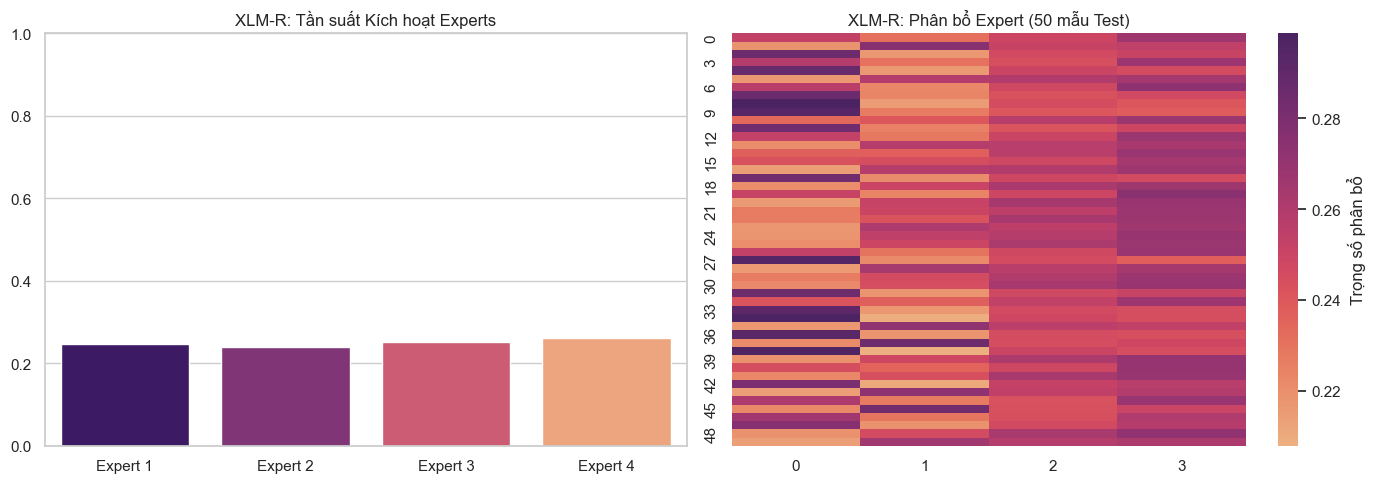


🎉 XIN CHÚC MỪNG! BẠN ĐÃ CHẠY THÀNH CÔNG TOÀN BỘ PIPELINE EXPERIMENTS!


In [9]:
print("\n" + "="*50)
print("📊 ĐÁNH GIÁ EXPERIMENT 3 TRÊN TEST SET (ViANLI)")
print("="*50)

xlmr_model.eval()
test_preds_xlmr, test_labels_xlmr, all_routing_weights_xlmr = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader_xlmr, desc="Testing XLM-R"):
        with autocast():
            logits, routing_weights = xlmr_model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        test_preds_xlmr.extend(torch.argmax(logits, dim=1).cpu().numpy())
        test_labels_xlmr.extend(batch['labels'].to(device).cpu().numpy())
        all_routing_weights_xlmr.append(routing_weights.cpu().numpy())

print(f"🎯 XLM-R TEST ACCURACY: {accuracy_score(test_labels_xlmr, test_preds_xlmr):.4f}")
print(f"🎯 XLM-R TEST MACRO-F1: {f1_score(test_labels_xlmr, test_preds_xlmr, average='macro'):.4f}")

# VẼ BIỂU ĐỒ
routing_matrix_xlmr = np.concatenate(all_routing_weights_xlmr, axis=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=[f"Expert {i+1}" for i in range(4)], y=routing_matrix_xlmr.mean(axis=0), palette="magma", ax=axes[0])
axes[0].set_title("XLM-R: Tần suất Kích hoạt Experts")
axes[0].set_ylim(0, 1.0)

sns.heatmap(routing_matrix_xlmr[:50], cmap="flare", cbar_kws={'label': 'Trọng số phân bổ'}, ax=axes[1])
axes[1].set_title("XLM-R: Phân bổ Expert (50 mẫu Test)")
plt.show()

print("\n🎉 XIN CHÚC MỪNG! BẠN ĐÃ CHẠY THÀNH CÔNG TOÀN BỘ PIPELINE EXPERIMENTS!")